# Text classification using pre-trained BERT model from huggingface

We aim to use the news text dataset to build model that classifies the news into 5 categories:
1. Politics
2. Sports
3. Technology
4. Entertainment
5. Business


# Installations and Imports

## Installations

In [1]:
!pip install -q torch transformers scikit-learn matplotlib seaborn tqdm wordcloud ipywidgets umap-learn

In [2]:
import transformers
transformers.__version__

'5.0.0'

## Importing necessary libraries and Modules

In [3]:
import os
import random
import datetime

# For loading and manipulating data
import pandas as pd
import numpy as np

# For creating the model architecture
import torch
import torch.nn as nn
from transformers import BertTokenizer, BertModel

# For preparing data and creating data loader for the model training
from torch.utils.data import Dataset, DataLoader, random_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold, cross_val_predict
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_selection import SelectKBest, chi2, f_classif
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import label_binarize

# For training optimizations
from torch.optim import AdamW

# Evaluation Metrics
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, precision_score, recall_score, roc_auc_score, roc_curve, auc, f1_score

# For Visualization
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
import seaborn as sns
from wordcloud import WordCloud

# Clear memory
import gc

# Progress bar
from tqdm import tqdm

import warnings
warnings.filterwarnings("ignore")

## Setting all the seeds for consistency within different runs

In [4]:
def set_all_seeds(seed):
    """
    Set all seeds for reproducibility
    """
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    np.random.seed(seed)
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)

In [5]:
SEED=43
set_all_seeds(SEED)

# Loading Dataset

In [6]:
# Loading the data
data_path = "/kaggle/input/datasets/tanishqdublish/text-classification-documentation/df_file.csv"
df = pd.read_csv(data_path)

In [7]:
df.columns

Index(['Text', 'Label'], dtype='object')

In [8]:
# From the dataset information, the classes are defined as follows
labels_dict = {0:'Politics', 1:'Sports',2:'Technology',3:'Entertainment', 4:'Business'}

## Exploratory Data Analysis (EDA)

In [9]:
# Check null
nullsum = df.isnull().sum()
df_null = pd.DataFrame()
df_null['count']=nullsum
df_null["%"] = df_null['count'].apply(lambda x: x/len(df))
df_null

,count,%
Text,0,0.0
Label,0,0.0


In [10]:
def get_top_n_words(corpus, n=20):
    # Using stop_words='english' to filter out common filler words
    vec = CountVectorizer(stop_words='english').fit(corpus)
    bag_of_words = vec.transform(corpus)
    sum_words = bag_of_words.sum(axis=0) 
    words_freq = [(word, sum_words[0, idx]) for word, idx in vec.vocabulary_.items()]
    words_freq = sorted(words_freq, key=lambda x: x[1], reverse=True)
    return words_freq[:n]

for label_id, label_name in labels_dict.items():
    class_texts = df[df['Label'] == label_id]['Text'].astype(str)
    top_words = get_top_n_words(class_texts, n=20)
    
    print(f"\n--- Top 20 words for {label_name} ---")
    # Extracting just the words for a clean printout
    print([word[0] for word in top_words])


--- Top 20 words for Politics ---
['said', 'mr', 'labour', 'government', 'people', 'election', 'party', 'blair', 'minister', 'new', 'brown', 'told', 'uk', 'public', 'howard', 'plans', 'prime', 'year', 'say', 'tory']

--- Top 20 words for Sports ---
['said', 'year', 'game', 'england', 'time', 'win', 'world', 'players', 'team', 'play', 'cup', 'new', 'just', 'second', 'match', 'ireland', 'half', 'final', 'wales', 'club']

--- Top 20 words for Technology ---
['said', 'people', 'new', 'mr', 'technology', 'mobile', 'users', 'games', 'music', 'use', 'digital', 'software', 'net', 'year', 'like', 'make', 'game', 'computer', 'phone', 'online']

--- Top 20 words for Entertainment ---
['said', 'film', 'best', 'year', 'music', 'new', 'awards', 'award', 'uk', 'won', 'years', 'number', 'star', 'band', 'director', 'tv', 'people', 'actor', 'mr', 'british']

--- Top 20 words for Business ---
['said', 'year', 'mr', 'market', 'new', 'company', 'growth', 'firm', 'economy', 'government', 'bank', 'sales', '

In [11]:
# Remove duplicates
print("Duplicates in the original dataset: ",df.duplicated().sum())
df = df.drop_duplicates(ignore_index = True)
print("Records after removing duplicates: ", len(df))

Duplicates in the original dataset:  98
Records after removing duplicates:  2127


In [12]:
df['Label'].value_counts()

Label
1    505
4    503
0    403
3    369
2    347
Name: count, dtype: int64

In [13]:
df['Label_name']=df['Label'].replace(labels_dict)

In [14]:
df['Label_name'].value_counts()

Label_name
Sports           505
Business         503
Politics         403
Entertainment    369
Technology       347
Name: count, dtype: int64

## Data Visualization

        category  count
0         Sports    505
1       Business    503
2       Politics    403
3  Entertainment    369
4     Technology    347


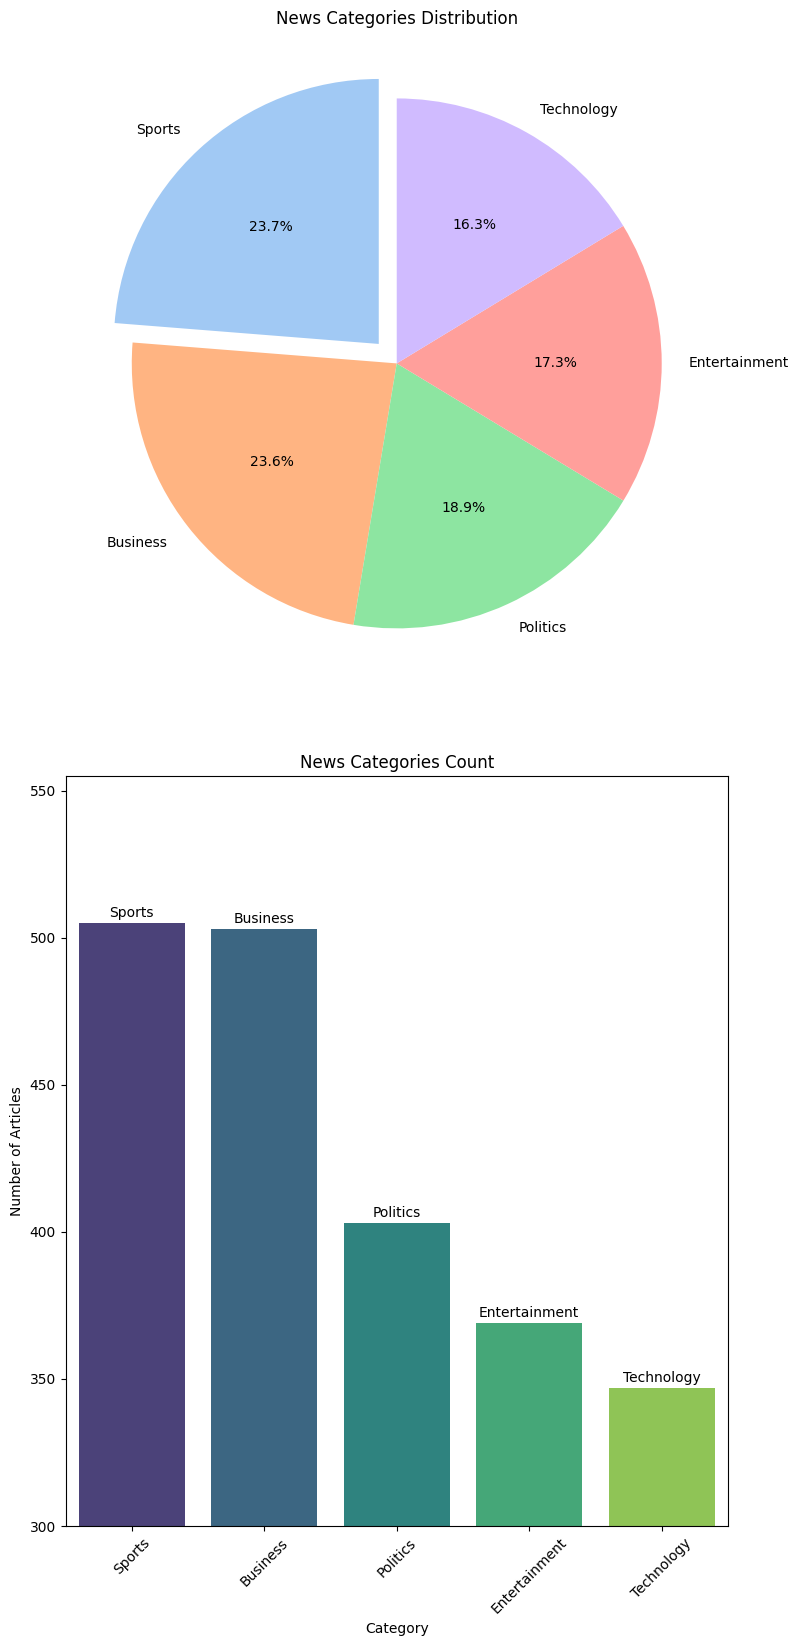

In [15]:
# Map labels to actual names for better visualization
df['category_name'] = df['Label'].map(labels_dict)
counts = df['category_name'].value_counts().reset_index()
counts.columns = ['category', 'count']
print(counts)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 17))

# 1. Pie Chart
# Find the index of the largest value to explode it
explode = [0.1 if i == counts['count'].argmax() else 0 for i in range(len(counts))]

ax1.pie(counts['count'], labels=counts['category'], autopct='%1.1f%%', 
        explode=explode, startangle=90, colors=sns.color_palette('pastel'))
ax1.set_title('News Categories Distribution')

# 2. Bar Chart
sns.barplot(data=counts, x='category', y='count', ax=ax2, palette='viridis')
ax2.set_title('News Categories Count')
ax2.set_ylabel('Number of Articles')
ax2.set_xlabel('Category')
ax2.tick_params(axis='x', rotation=45)
ax2.set_ylim(300, counts['count'].max()+50)
i=0
for h, cat in list(zip(counts['count'], counts['category'])):
    ax2.text(i, h + 2, str(cat), ha='center')
    i+=1

plt.tight_layout()
plt.savefig("Data_Distribution_plot.png")
plt.show()

## Generating word cloud to visualize words

In [16]:
from wordcloud import STOPWORDS
print("Type of Stopwords: ",type(STOPWORDS))
print(f"Length of default stopwords: {len(STOPWORDS)}")
print("said" in STOPWORDS)

Type of Stopwords:  <class 'set'>
Length of default stopwords: 192
False


In [17]:
add_stopwords = ["will", "said", "mr", "year","people","uk"]
add_stopwords = add_stopwords + ["Will", "Said", "Mr", "Year", "People","UK","Uk"]
modified_stopwords = set(STOPWORDS)
modified_stopwords.update(add_stopwords)
print(f"Type of modified_stopwords: {type(modified_stopwords)}. \nLength of default stopwords: {len(STOPWORDS)} \nLength of modified stopwords: {len(modified_stopwords)}")

Type of modified_stopwords: <class 'set'>. 
Length of default stopwords: 192 
Length of modified stopwords: 205


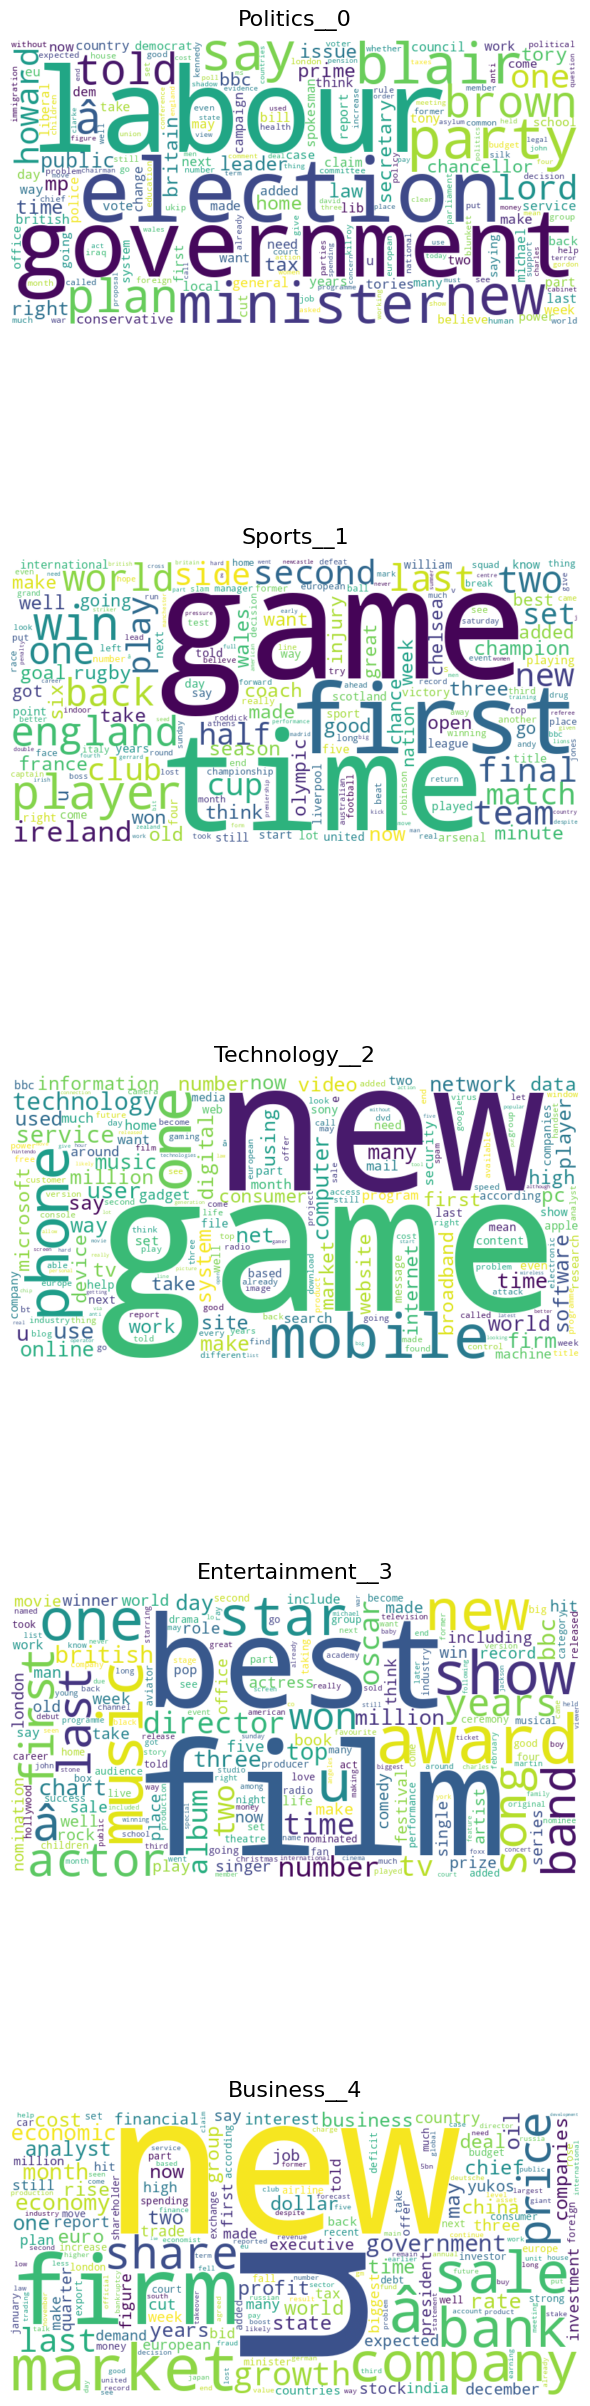

In [18]:
# Figure with rows and 1 column
fig, axes = plt.subplots(5, 1, figsize=(6, 27))
axes = axes.flatten()

for i, (label_id, label_name) in enumerate(labels_dict.items()):
    # Combine all text for the specific category
    text_data = " ".join(df[df['Label'] == label_id]['Text'].astype(str)).lower()
    
    # Generate WordCloud
    wordcloud = WordCloud(width=800, height=400, 
                          background_color='white', 
                          stopwords=modified_stopwords,
                         collocations=False).generate(text_data)
    
    # Plot on the corresponding subplot
    axes[i].imshow(wordcloud, interpolation='bilinear')
    axes[i].set_title(f"{label_name}__{label_id}", fontsize=16, pad=10)
    axes[i].axis('off')

axes[-1].axis('off') 

plt.tight_layout()
plt.savefig("WordCloud.png")
plt.show()

## Data Preprocessing

In [19]:
import re
def preprocessing_text(text):
    """
    Minimal preprocessing for BERT:
    - Removes URLs
    - Removes HTML tags (if any)
    - Normalizes whitespace
    """
    # Remove URLs
    text = re.sub(r'http\S+|www\.\S+', '', str(text))
    
    # Remove HTML tags
    text = re.sub(r'<.*?>', '', text)
    
    # Replace multiple spaces/newlines with a single space
    text = re.sub(r'\s+', ' ', text)

    # Collapses multiple occurrences of ".", "#", "@", "!", "%" into a single instance
    text = re.sub(r'([#@!%.])\1+', r'\1', text)
    text=text.lower()
    
    # Strip leading/trailing whitespace
    return text.strip()

In [20]:
def get_length_of_words(text):
    text = preprocessing_text(text)
    return len(text.split(" "))

In [21]:
get_length_of_words(df['Text'][3])

496

In [22]:
df['text_clean_for_bert']=df['Text'].apply(preprocessing_text)

In [23]:
df['Length']=df['Text'].apply(get_length_of_words)

In [24]:
df[["Length"]].describe()

,Length
count,2127.000000
mean,384.111895
std,241.399611
min,89.000000
25%,245.000000
50%,331.000000
75%,471.000000
max,4432.000000


## Dimensionality reduction for visualization

In [34]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
DEVICE=torch.device("cpu")
print(f"Using device: {DEVICE}")

Using device: cpu


In [35]:
import umap
PALETTE = {
    'Politics':      '#E63946',
    'Sports':        '#2196F3',
    'Technology':    '#4CAF50',
    'Entertainment': '#FF9800',
    'Business':      '#9C27B0',
}

MODEL_NAME = "bert-base-uncased"
BATCH_SIZE = 16

In [36]:
df["Label"]    = df["Label"].astype(int)
df["Category"] = df["Label"].map(labels_dict)

## Data Loader for feature reduction

In [43]:
import time
# Creating our custom Dataset Class
class DimensionReductionDataset(Dataset):
    def __init__(self, texts, tokenizer, max_length=512):
        self.texts = texts.tolist() if hasattr(texts,'tolist') else list(texts)
        self.tokenizer = tokenizer
        self.max_length = max_length
        self.preprocess_text()

    def __len__(self):
        return len(self.texts)
    
    def __getitem__(self, idx):
        
        encoding = self.tokenizer(
            self.texts[idx],
            add_special_tokens=True,
            max_length=self.max_length,
            padding='max_length',
            truncation=True,
            return_attention_mask=True,
            return_tensors='pt'
        )
        
        return {
            'input_ids': encoding['input_ids'].squeeze(0),
            'attention_mask': encoding['attention_mask'].squeeze(0),
        }

    def preprocess_text(self):
        texts=[]
        for text in self.texts:
            texts.append(preprocessing_text(text))
        self.texts=texts
        return

In [38]:
print("Loading BERT...")
tokenizer  = BertTokenizer.from_pretrained(MODEL_NAME)
bert_model = BertModel.from_pretrained(MODEL_NAME)
bert_model.eval()
bert_model.to(DEVICE)

Loading BERT...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


BertModel(
  (embeddings): BertEmbeddings(
    (word_embeddings): Embedding(30522, 768, padding_idx=0)
    (position_embeddings): Embedding(512, 768)
    (token_type_embeddings): Embedding(2, 768)
    (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (encoder): BertEncoder(
    (layer): ModuleList(
      (0-11): 12 x BertLayer(
        (attention): BertAttention(
          (self): BertSelfAttention(
            (query): Linear(in_features=768, out_features=768, bias=True)
            (key): Linear(in_features=768, out_features=768, bias=True)
            (value): Linear(in_features=768, out_features=768, bias=True)
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (output): BertSelfOutput(
            (dense): Linear(in_features=768, out_features=768, bias=True)
            (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
            (dropout): Dropout(p=0.1, inplace=False)
  

In [44]:
dataset    = DimensionReductionDataset(df["Text"].tolist(), tokenizer)
dataloader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=False)

In [45]:
print("Torch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("CUDA version:", torch.version.cuda)
print("GPU:", torch.cuda.get_device_name(0))

Torch: 2.10.0+cu128
CUDA available: True
CUDA version: 12.8
GPU: Tesla P100-PCIE-16GB


In [46]:
!nvidia-smi

Thu Apr 30 04:54:27 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.105.08             Driver Version: 580.105.08     CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla P100-PCIE-16GB           Off |   00000000:00:04.0 Off |                    0 |
| N/A   34C    P0             31W /  250W |     731MiB /  16384MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [47]:
all_embeddings = []
print("Generating embeddings...")
with torch.no_grad():
    for batch in tqdm(dataloader, desc="Encoding", unit='Batch'):
        input_ids      = batch["input_ids"].to(DEVICE)
        attention_mask = batch["attention_mask"].to(DEVICE)
        outputs        = bert_model(input_ids=input_ids, attention_mask=attention_mask)
        cls_emb        = outputs.last_hidden_state[:, 0, :]
        all_embeddings.append(cls_emb.cpu().numpy())

embeddings = np.vstack(all_embeddings)
print(f"Embeddings shape: {embeddings.shape}")

Generating embeddings...


Encoding: 100%|██████████| 133/133 [18:20<00:00,  8.27s/Batch]

Embeddings shape: (2127, 768)


## Fitting U-Map 2D and 3D

In [48]:
emb_2d = umap.UMAP(n_components=2, n_neighbors=30, min_dist=0.1,
                   metric="cosine", random_state=SEED).fit_transform(embeddings)

In [49]:
emb_3d = umap.UMAP(n_components=3, n_neighbors=30, min_dist=0.1,
                   metric="cosine", random_state=SEED).fit_transform(embeddings)

In [50]:
categories = df["Category"].values

## Umap Plots

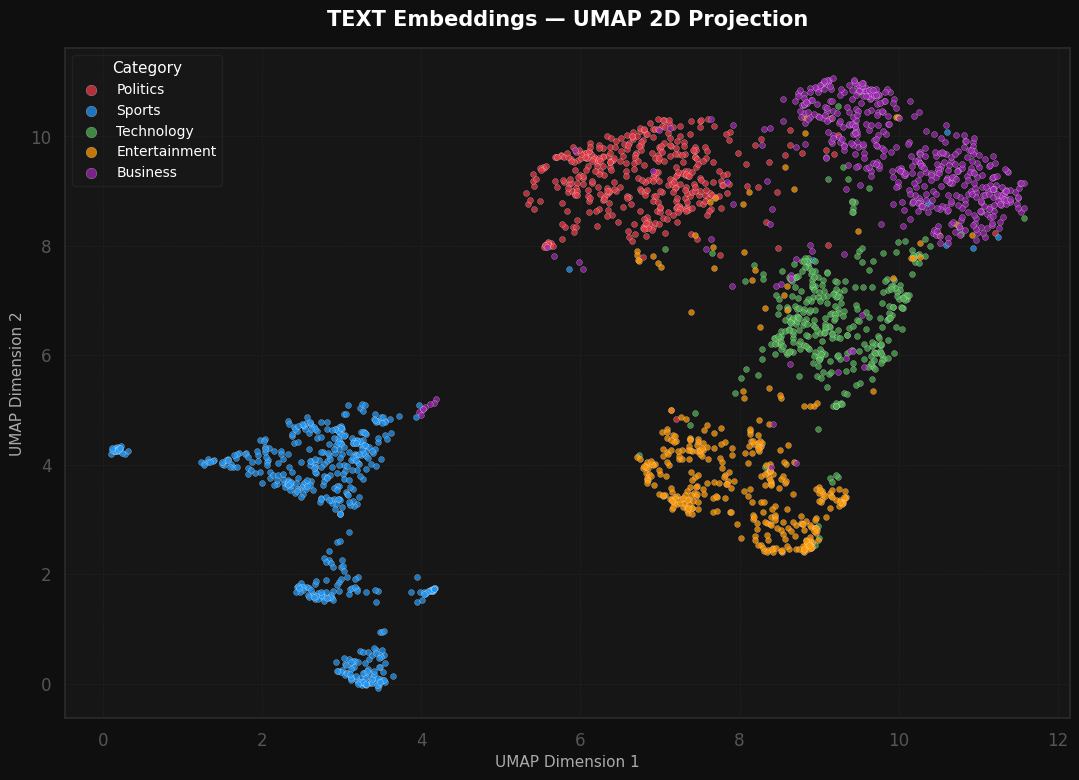

In [51]:
sns.set_theme(style="dark", font_scale=1.1)

fig, ax = plt.subplots(figsize=(11, 8))
fig.patch.set_facecolor("#0f0f0f")
ax.set_facecolor("#161616")

# Plot each category separately for clean legend control
for cat, color in PALETTE.items():
    mask = categories == cat
    ax.scatter(
        emb_2d[mask, 0], emb_2d[mask, 1],
        c       = color,
        label   = cat,
        s       = 18,
        alpha   = 0.75,
        linewidths = 0.2,
        edgecolors = "white",
    )


ax.set_title("TEXT Embeddings — UMAP 2D Projection",
             color="white", fontsize=15, fontweight="bold", pad=16)
ax.set_xlabel("UMAP Dimension 1", color="#aaaaaa", fontsize=11)
ax.set_ylabel("UMAP Dimension 2", color="#aaaaaa", fontsize=11)
ax.tick_params(colors="#555555")
for spine in ax.spines.values():
    spine.set_edgecolor("#2a2a2a")
ax.grid(True, color="#2a2a2a", linewidth=0.5, linestyle="--", alpha=0.6)

legend = ax.legend(
    title          = "Category",
    title_fontsize = 11,
    fontsize       = 10,
    framealpha     = 0.25,
    facecolor      = "#1a1a1a",
    edgecolor      = "#444444",
    labelcolor     = "white",
    markerscale    = 1.8,
    loc            = "best",
)
legend.get_title().set_color("white")

plt.tight_layout()
plt.savefig("bert_umap_2d.png", dpi=180, bbox_inches="tight", facecolor=fig.get_facecolor())
plt.show()

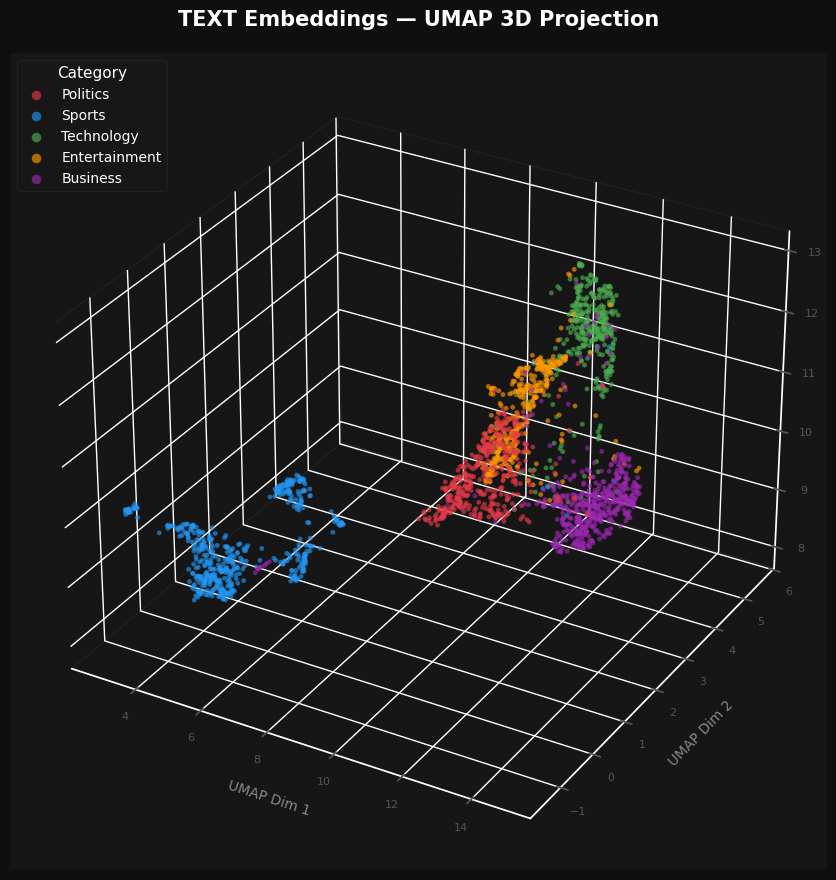

In [52]:
fig3d = plt.figure(figsize=(13, 9))
fig3d.patch.set_facecolor("#0f0f0f")
ax3d  = fig3d.add_subplot(111, projection="3d")
ax3d.set_facecolor("#161616")

for cat, color in PALETTE.items():
    mask = categories == cat
    ax3d.scatter(
        emb_3d[mask, 0],
        emb_3d[mask, 1],
        emb_3d[mask, 2],
        c          = color,
        label      = cat,
        s          = 12,
        alpha      = 0.65,
        linewidths = 0,
        depthshade = True,
    )

ax3d.set_title("TEXT Embeddings — UMAP 3D Projection",
               color="white", fontsize=15, fontweight="bold", pad=20)
ax3d.set_xlabel("UMAP Dim 1", color="#888888", fontsize=10, labelpad=8)
ax3d.set_ylabel("UMAP Dim 2", color="#888888", fontsize=10, labelpad=8)
ax3d.set_zlabel("UMAP Dim 3", color="#888888", fontsize=10, labelpad=8)

ax3d.xaxis.pane.fill = False
ax3d.yaxis.pane.fill = False
ax3d.zaxis.pane.fill = False
ax3d.xaxis.pane.set_edgecolor("#2a2a2a")
ax3d.yaxis.pane.set_edgecolor("#2a2a2a")
ax3d.zaxis.pane.set_edgecolor("#2a2a2a")
ax3d.tick_params(colors="#555555", labelsize=8)
ax3d.grid(True, color="#2a2a2a", linewidth=0.4)

legend3d = ax3d.legend(
    title          = "Category",
    title_fontsize = 11,
    fontsize       = 10,
    framealpha     = 0.25,
    facecolor      = "#1a1a1a",
    edgecolor      = "#444444",
    labelcolor     = "white",
    markerscale    = 2.0,
    loc            = "upper left",
)
legend3d.get_title().set_color("white")

plt.tight_layout()
plt.savefig("bert_umap_3d.png", dpi=180, bbox_inches="tight", facecolor=fig3d.get_facecolor())
plt.show()

## Cleaning Memory

In [53]:
del bert_model, tokenizer, emb_3d, emb_2d, embeddings, all_embeddings, dataset, dataloader

In [54]:
torch.cuda.empty_cache() if torch.cuda.is_available() else gc.collect()

# Plotting Functions

In [55]:
def preprocess_text_for_mnb(text):
    # Lowercase
    text = text.lower()
    
    # Remove URLs
    text = re.sub(r'http\S+|www\S+', '', text)
    
    # Remove punctuation (keep words only)
    text = re.sub(r'[^a-z\s]', '', text)
    
    # Remove extra whitespace
    text = re.sub(r'\s+', ' ', text).strip()
    
    return text

In [56]:
def preprocess_text_for_knn(text):
    # Lowercase
    text = text.lower()
    
    # Remove URLs
    text = re.sub(r'http\S+|www\S+', '', text)
    
    # Remove punctuation (keep words only)
    text = re.sub(r'[^a-z\s]', '', text)
    
    # Remove extra whitespace
    text = re.sub(r'\s+', ' ', text).strip()
    
    return text

In [57]:
df['text_clean_for_mnb'] = df['Text'].apply(preprocess_text_for_mnb)
texts=df['text_clean_for_mnb'].values
labels=df['Label'].values

In [58]:
df['text_clean_for_knn'] = df['Text'].apply(preprocess_text_for_knn)

In [59]:
# Split data into test and train_val
test_ratio=0.2
X_train, X_test, y_train, y_test = train_test_split(
texts, labels, test_size=test_ratio, stratify=labels, random_state=SEED
)

In [60]:
X = df['text_clean_for_knn'].values
y = df['Label'].values

# One outer fold → ~80 % train | ~20 % holdout
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=SEED,
    stratify=y
)

In [62]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [63]:
_tfidf_probe = TfidfVectorizer(
    ngram_range=(1, 2), max_df=0.75, min_df=2, stop_words='english'
)
X_train_tfidf = _tfidf_probe.fit_transform(X_train)
print(f"TF-IDF feature matrix shape : {X_train_tfidf.shape}")

TF-IDF feature matrix shape : (1701, 48296)


# Feature Selection - Chi-Squared, Anova

In [64]:
# 1 – Chi-Squared  (non-negative, great for discrete/count-like data)
chi2_selector  = SelectKBest(chi2, k=5000)
# 2 – Anova (model-free, captures non-linear dependence)
anova_selector = SelectKBest(f_classif, k=5000)

chi2_selector.fit(X_train_tfidf, y_train)
anova_selector.fit(X_train_tfidf,   y_train)

# Peek at top-20 features per selector
feature_names = np.array(_tfidf_probe.get_feature_names_out())

top_chi2 = feature_names[np.argsort(chi2_selector.scores_)[::-1][:20]]
top_anova   = feature_names[np.argsort(anova_selector.scores_)[::-1][:20]]

print(f"\n📌 Top-20 features — Chi²:\n{top_chi2}")
print(f"\n📌 Top-20 features — Anova:\n{top_anova}")


📌 Top-20 features — Chi²:
['film' 'labour' 'blair' 'election' 'bn' 'mr' 'users' 'party' 'mobile'
 'software' 'technology' 'broadband' 'mr blair' 'band' 'album' 'computer'
 'cup' 'festival' 'music' 'oil']

📌 Top-20 features — Anova:
['mr' 'film' 'labour' 'users' 'bn' 'technology' 'secretary' 'election'
 'tony' 'leader' 'minister' 'tony blair' 'people' 'government' 'blair'
 'party' 'win' 'tory' 'tories' 'computer']


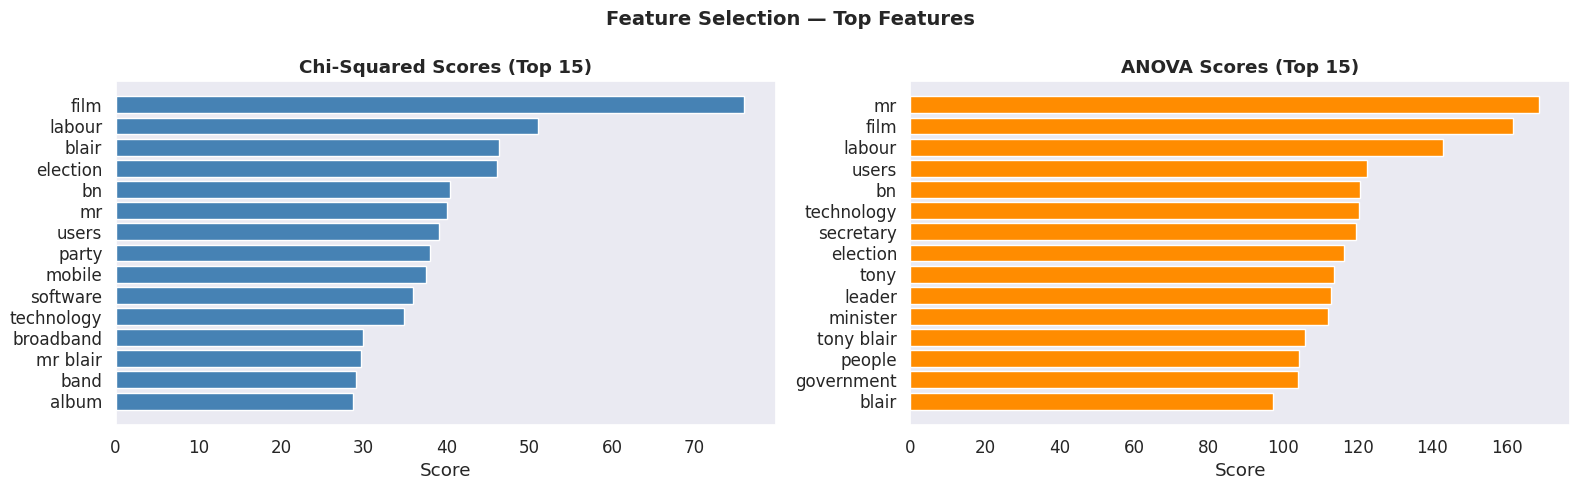

In [65]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
for ax, scores, title, color in zip(
        axes,
        [chi2_selector.scores_, anova_selector.scores_],
        ['Chi-Squared Scores (Top 15)', 'ANOVA Scores (Top 15)'],
        ['steelblue', 'darkorange']):
    idx = np.argsort(scores)[::-1][:15]
    ax.barh(feature_names[idx][::-1], scores[idx][::-1], color=color)
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Score')
plt.suptitle('Feature Selection — Top Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('feature_selection_comparison.png', bbox_inches='tight')
plt.show()

In [66]:
df.sample(10)

,Text,Label,Label_name,category_name,text_clean_for_bert,Length,Category,text_clean_for_mnb,text_clean_for_knn
1878,Ukraine strikes Turkmen gas deal\n \n Ukraine ...,4,Business,Business,ukraine strikes turkmen gas deal ukraine has a...,228,Business,ukraine strikes turkmen gas deal ukraine has a...,ukraine strikes turkmen gas deal ukraine has a...
549,Wright-Phillips to start on right\n \n England...,1,Sports,Sports,wright-phillips to start on right england coac...,241,Sports,wrightphillips to start on right england coach...,wrightphillips to start on right england coach...
1495,Fockers keeps US box office lead\n \n Film com...,3,Entertainment,Entertainment,fockers keeps us box office lead film comedy m...,213,Entertainment,fockers keeps us box office lead film comedy m...,fockers keeps us box office lead film comedy m...
1001,Microsoft makes anti-piracy move\n \n Microsof...,2,Technology,Technology,microsoft makes anti-piracy move microsoft say...,445,Technology,microsoft makes antipiracy move microsoft says...,microsoft makes antipiracy move microsoft says...
15,Brown targets OAPs and homebuyers\n \n Gordon ...,0,Politics,Politics,brown targets oaps and homebuyers gordon brown...,717,Politics,brown targets oaps and homebuyers gordon brown...,brown targets oaps and homebuyers gordon brown...
559,Williams battles to Aussie title\n \n Serena W...,1,Sports,Sports,williams battles to aussie title serena willia...,376,Sports,williams battles to aussie title serena willia...,williams battles to aussie title serena willia...
1167,Attack prompts Bush site block\n \n The offici...,2,Technology,Technology,attack prompts bush site block the official re...,594,Technology,attack prompts bush site block the official re...,attack prompts bush site block the official re...
2121,Stock market eyes Japan recovery\n \n Japanese...,4,Business,Business,stock market eyes japan recovery japanese shar...,156,Business,stock market eyes japan recovery japanese shar...,stock market eyes japan recovery japanese shar...
1153,Text message record smashed\n \n UK mobile own...,2,Technology,Technology,text message record smashed uk mobile owners c...,327,Technology,text message record smashed uk mobile owners c...,text message record smashed uk mobile owners c...
1831,US trade deficit widens sharply\n \n The gap b...,4,Business,Business,us trade deficit widens sharply the gap betwee...,416,Business,us trade deficit widens sharply the gap betwee...,us trade deficit widens sharply the gap betwee...


In [67]:
df.to_csv("/kaggle/working/preprocessed_data.csv", index=True)